In [173]:
import numpy as np 
import pandas as pd

In [174]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

In [175]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [177]:
df.shape

(9994, 21)

In [178]:
print('Statical Summary of df')
df.describe()

Statical Summary of df


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Find Missing Values


In [179]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [180]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])


# # Remove Duplicates Items

In [181]:
df.duplicated().sum()


np.int64(0)

In [182]:
df.shape

(9994, 21)

## Handle Outlier

In [183]:
Q1 = df['Sales'].quantile(0.25)
print(Q1)

17.28


In [184]:
Q3 = df['Sales'].quantile(0.75)
print(Q3)

209.94


In [185]:
IQR = Q3 -Q1
print(IQR)

192.66


In [186]:
lower = Q1 - 1.5*IQR
upper = Q3 -1.5*IQR
print(lower)
print(upper)

-271.71000000000004
-79.05000000000001


In [187]:
df_clean = df[~((df['Sales'] < lower) | (df['Sales'] > upper))]
print(df_clean)

Empty DataFrame
Columns: [Row ID, Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Customer Name, Segment, Country, City, State, Postal Code, Region, Product ID, Category, Sub-Category, Product Name, Sales, Quantity, Discount, Profit]
Index: []

[0 rows x 21 columns]


In [188]:
df.shape[0]


9994

In [189]:
df_clean.shape[0]


0

In [190]:
df.shape[0] - df_clean.shape[0]

9994

In [191]:
print(df_clean.to_csv('Cleaned_superstore.csv', index = False))

None


## Data Visualizations

In [192]:
import matplotlib.pyplot as plt
import seaborn as sns

In [193]:
data = df

### Sales Distribution 

### Category sales

### Region Sales

### Monthly Rush

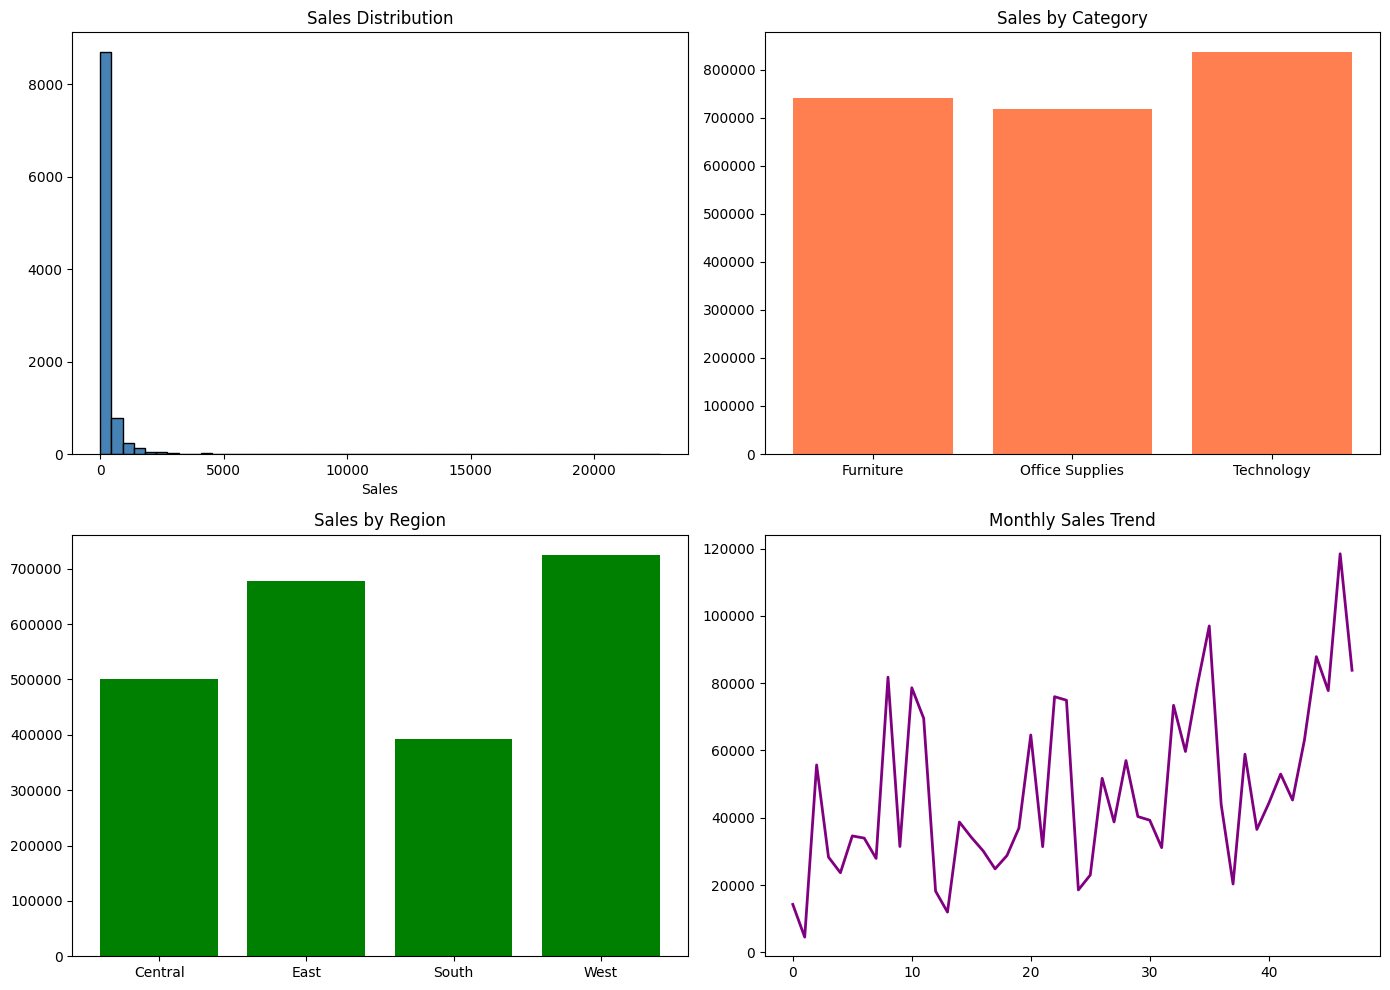

In [194]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


data = df  

axes[0,0].hist(data['Sales'], bins=50, color='steelblue', edgecolor='black')
axes[0,0].set_title('Sales Distribution')
axes[0,0].set_xlabel('Sales')


cat_sales = data.groupby('Category')['Sales'].sum()
axes[0,1].bar(cat_sales.index, cat_sales.values, color='coral')
axes[0,1].set_title('Sales by Category')


reg_sales = data.groupby('Region')['Sales'].sum()
axes[1,0].bar(reg_sales.index, reg_sales.values, color='green')
axes[1,0].set_title('Sales by Region')


data['Month'] = data['Order Date'].dt.to_period('M')
monthly = data.groupby('Month')['Sales'].sum()
axes[1,1].plot(monthly.values, color='purple', linewidth=2)
axes[1,1].set_title('Monthly Sales Trend')

plt.tight_layout()
plt.savefig('EDA_graphs.png')
plt.show()


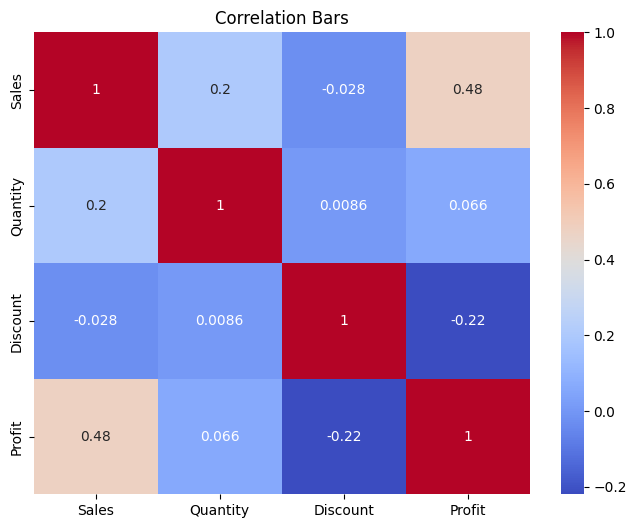

In [195]:

plt.figure(figsize=(8,6))
numeric_cols = df[['Sales','Quantity','Discount','Profit']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Bars')
plt.savefig('Bars.png')
plt.show()

In [196]:
print("*"*100)
print("KEY INSIGHTS - Task 1")
print("*"*100)
print(f"1. Total Sales: ${df['Sales'].sum():,.2f}")
print(f"2. Top Category: {df.groupby('Category')['Sales'].sum().idxmax()}")
print(f"3. Top Region: {df.groupby('Region')['Sales'].sum().idxmax()}")
print(f"4. Avg Discount: {df['Discount'].mean():.2%}")
print(f"5. Total Profit: ${df['Profit'].sum():,.2f}")
print("*"*100)

****************************************************************************************************
KEY INSIGHTS - Task 1
****************************************************************************************************
1. Total Sales: $2,297,200.86
2. Top Category: Technology
3. Top Region: West
4. Avg Discount: 15.62%
5. Total Profit: $286,397.02
****************************************************************************************************
